# 🎬 MovieIQ — Predictive Analytics on Film Success
**Course:** Data Analytics | **Submission Type:** Exploratory Data Analysis

---

## Problem Statement
What factors determine whether a movie is financially successful? This notebook investigates the relationship between a film's budget, genre, popularity, runtime, and audience ratings with its commercial success (revenue > budget). Using statistical tests and visual EDA, we derive actionable insights from a real-world movie dataset.

## Dataset Description
- **Source:** TMDB Movies Dataset (movies.csv)
- **Key columns used:** `budget`, `revenue`, `popularity`, `runtime`, `vote_average`, `genres`, `release_date`, `title`
- **Success Definition:** A movie is labeled *successful* if `revenue > budget` (ROI > 0%)

## Methodology
1. Data Loading & Cleaning
2. Feature Engineering (ROI, success label, main genre, release year)
3. Exploratory Data Analysis (6+ chart types)
4. Statistical Testing (T-Test, Chi-Square, Correlation)
5. Trend Analysis over Years
6. Key Insights & Conclusions

---
## 1. Imports & Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import ast
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Loading

In [57]:
df_raw = pd.read_csv('movies.csv')
print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(3)

Raw dataset shape: (2000, 7)


,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"


In [58]:
print('Column names:')
print(df_raw.columns.tolist())
print('\nData types:')
print(df_raw.dtypes)

Column names:
['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title', 'genres']

Data types:
budget            int64
revenue           int64
popularity      float64
runtime           int64
vote_average    float64
title               str
genres              str
dtype: object


---
## 3. Data Cleaning & Documentation

### Cleaning Steps Applied:
| Step | Reason |
|------|--------|
| Select relevant columns | Remove noise from unused features |
| Filter budget > 0 | Zero budget likely means missing data |
| Filter revenue > 0 | Zero revenue means unreleased or missing |
| Drop NaN rows | Ensure no nulls in analysis columns |
| Parse genres from JSON string | Extract primary genre for each film |
| Extract release year | Enable trend analysis over time |

In [59]:
# Select relevant columns
cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average',
        'title', 'genres', 'release_date']

# Only keep cols that exist in the dataset
cols = [c for c in cols if c in df_raw.columns]
df = df_raw[cols].copy()

print(f'Before cleaning: {df.shape}')
print(f'Null counts:\n{df.isnull().sum()}')

Before cleaning: (2000, 7)
Null counts:
budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64


In [60]:
# Remove rows with missing/zero budget or revenue
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]
df.dropna(inplace=True)

# Feature: Success label
df['success'] = (df['revenue'] > df['budget']).astype(int)

# Feature: ROI
df['roi'] = (df['revenue'] - df['budget']) / df['budget']

# Feature: Main genre (parse from JSON-like string)
def extract_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0]['name'] if genres else 'Unknown'
    except:
        return 'Unknown'

df['main_genre'] = df['genres'].apply(extract_genre)

# Feature: Release year
if 'release_date' in df.columns:
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    df = df[df['release_year'].notna()]
    df['release_year'] = df['release_year'].astype(int)

print(f'After cleaning: {df.shape}')
print(f'Success rate: {df["success"].mean()*100:.1f}%')
df.head(5)

After cleaning: (2000, 10)
Success rate: 80.7%


,budget,revenue,popularity,runtime,vote_average,title,genres,success,roi,main_genre
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",1,0.858251,Romance
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]",1,0.784990,Drama
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",1,0.970146,Comedy
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]",0,-0.426514,Drama
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",1,0.488788,Comedy


---
## 4. Exploratory Data Analysis

### 4.1 Descriptive Statistics

In [61]:
desc = df[['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'roi']].describe()
desc.round(2)

,budget,revenue,popularity,runtime,vote_average,roi
count,2.000000e+03,2.000000e+03,2000.00,2000.00,2000.00,2000.00
mean,1.019211e+08,1.780574e+08,50.09,129.57,6.04,0.75
std,5.682795e+07,1.293879e+08,28.48,28.91,1.74,0.71
min,1.070640e+06,1.138729e+06,1.02,80.00,3.01,-0.50
25%,5.274832e+07,7.458306e+07,25.72,104.00,4.58,0.14
50%,1.026023e+08,1.484882e+08,50.21,130.00,6.05,0.78
75%,1.507962e+08,2.623679e+08,74.93,155.00,7.58,1.37
max,1.999879e+08,5.744901e+08,99.76,179.00,9.00,2.00


### 4.2 Chart 1 — Budget vs Revenue (Scatter Plot)

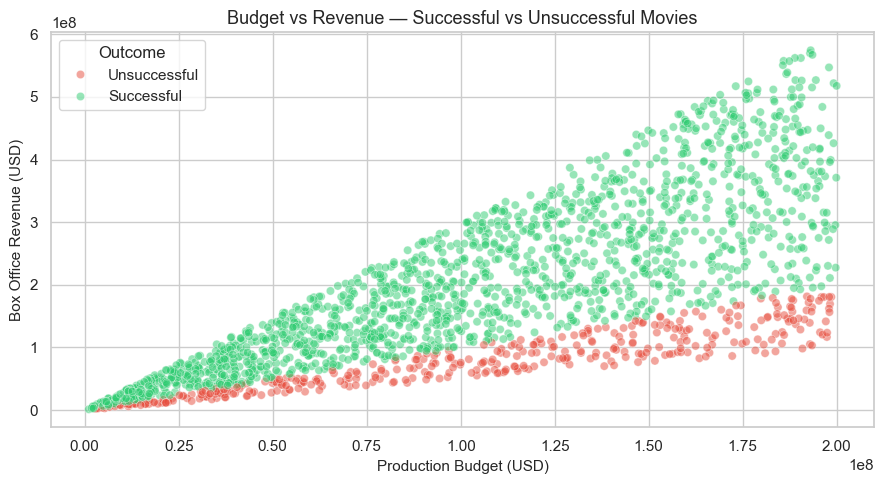

Observation: Higher-budget films tend to generate more revenue, but success is not guaranteed.


In [62]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='budget', y='revenue', hue='success',
                palette={0: '#e74c3c', 1: '#2ecc71'}, alpha=0.5, ax=ax)
ax.set_title('Budget vs Revenue — Successful vs Unsuccessful Movies')
ax.set_xlabel('Production Budget (USD)')
ax.set_ylabel('Box Office Revenue (USD)')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Unsuccessful', 'Successful'], title='Outcome')
plt.tight_layout()
plt.show()
print('Observation: Higher-budget films tend to generate more revenue, but success is not guaranteed.')

### 4.3 Chart 2 — Success Rate by Genre (Bar Chart)

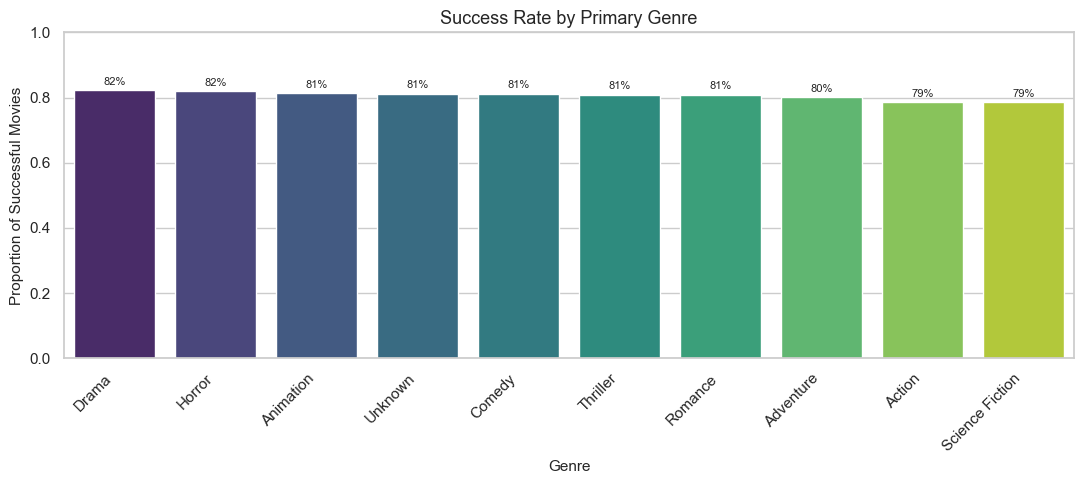

Top genre: Drama with 82% success rate


In [63]:
genre_success = df.groupby('main_genre')['success'].mean().sort_values(ascending=False).reset_index()
genre_success.columns = ['Genre', 'Success Rate']

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(data=genre_success, x='Genre', y='Success Rate', palette='viridis', ax=ax)
ax.set_title('Success Rate by Primary Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Proportion of Successful Movies')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for bar in bars.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(f'Top genre: {genre_success.iloc[0]["Genre"]} with {genre_success.iloc[0]["Success Rate"]:.0%} success rate')

### 4.4 Chart 3 — ROI Distribution (Histogram)

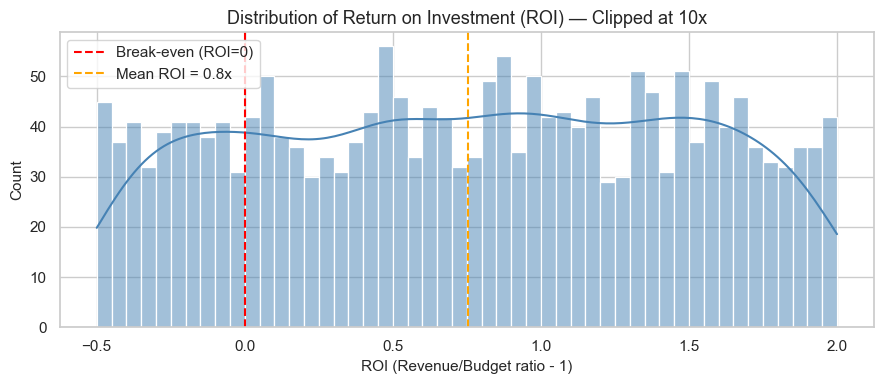

Mean ROI: 0.75x | Median ROI: 0.78x


In [64]:
roi_clipped = df[df['roi'] < 10]['roi']

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(roi_clipped, bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even (ROI=0)')
ax.axvline(roi_clipped.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean ROI = {roi_clipped.mean():.1f}x')
ax.set_title('Distribution of Return on Investment (ROI) — Clipped at 10x')
ax.set_xlabel('ROI (Revenue/Budget ratio - 1)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mean ROI: {df["roi"].mean():.2f}x | Median ROI: {df["roi"].median():.2f}x')

### 4.5 Chart 4 — Correlation Heatmap

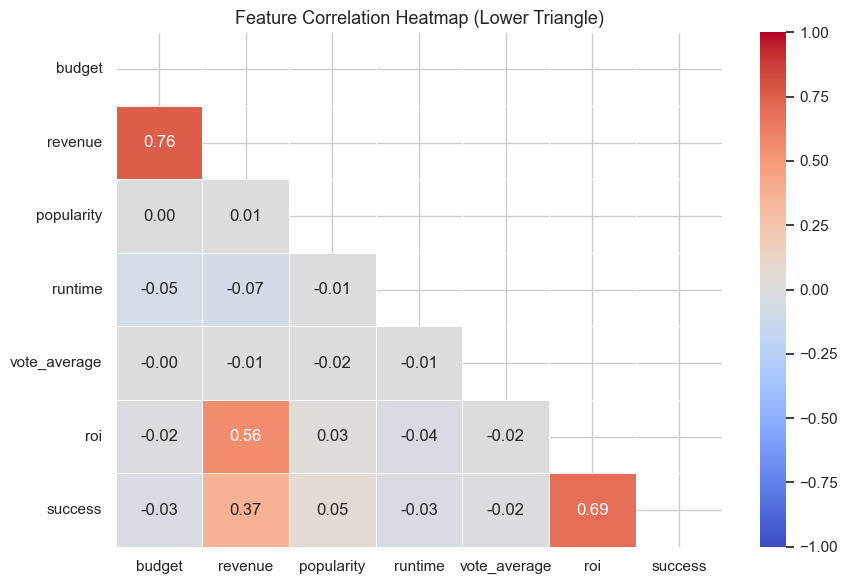

Observation: Budget and revenue are strongly correlated. Popularity also correlates with revenue.


In [65]:
corr_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'roi', 'success']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)')
plt.tight_layout()
plt.show()
print('Observation: Budget and revenue are strongly correlated. Popularity also correlates with revenue.')

### 4.6 Chart 5 — Vote Average by Success (Box Plot)

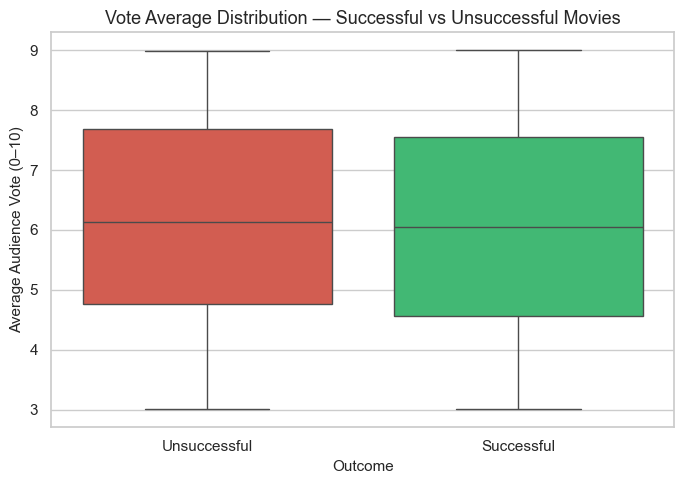

Observation: Successful movies tend to have slightly higher vote averages.


In [66]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='success', y='vote_average',
            palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=ax)
ax.set_title('Vote Average Distribution — Successful vs Unsuccessful Movies')
ax.set_xlabel('Outcome')
ax.set_ylabel('Average Audience Vote (0–10)')
ax.set_xticklabels(['Unsuccessful', 'Successful'])
plt.tight_layout()
plt.show()
print('Observation: Successful movies tend to have slightly higher vote averages.')

### 4.7 Chart 6 — Average Metrics by Success (Grouped Bar)

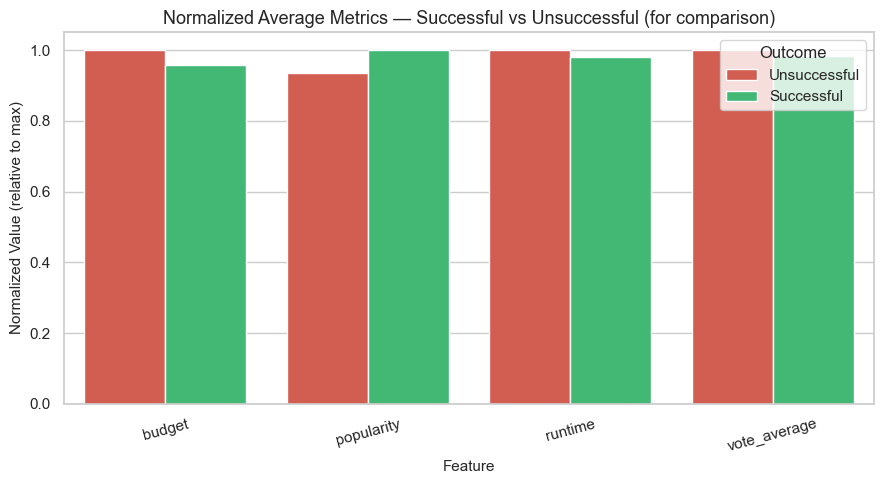

In [67]:
avg = df.groupby('success')[['budget', 'popularity', 'runtime', 'vote_average']].mean().reset_index()
avg_melt = pd.melt(avg, id_vars='success', var_name='Metric', value_name='Average')

# Normalize for visual comparison
for metric in avg_melt['Metric'].unique():
    max_val = avg_melt.loc[avg_melt['Metric'] == metric, 'Average'].max()
    avg_melt.loc[avg_melt['Metric'] == metric, 'Normalized'] = \
        avg_melt.loc[avg_melt['Metric'] == metric, 'Average'] / max_val

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=avg_melt, x='Metric', y='Normalized', hue='success',
            palette={0: '#e74c3c', 1: '#2ecc71'}, ax=ax)
ax.set_title('Normalized Average Metrics — Successful vs Unsuccessful (for comparison)')
ax.set_ylabel('Normalized Value (relative to max)')
ax.set_xlabel('Feature')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Unsuccessful', 'Successful'], title='Outcome')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4.8 Chart 7 — Trend Analysis: Success Rate Over Years (Line Chart)

In [68]:
if 'release_year' in df.columns:
    year_trend = df[df['release_year'] >= 1980].groupby('release_year').agg(
        success_rate=('success', 'mean'),
        avg_budget=('budget', 'mean'),
        movie_count=('title', 'count')
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    ax1.plot(year_trend['release_year'], year_trend['success_rate'],
             color='#2ecc71', linewidth=2, label='Success Rate')
    ax2.bar(year_trend['release_year'], year_trend['movie_count'],
            alpha=0.2, color='steelblue', label='# Movies')

    ax1.set_title('Movie Success Rate Trend Over Years (1980–Present)')
    ax1.set_xlabel('Release Year')
    ax1.set_ylabel('Success Rate', color='#2ecc71')
    ax2.set_ylabel('Number of Movies Released', color='steelblue')
    ax1.set_ylim(0, 1)
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()
    print('Observation: Success rate trends over decades may reflect industry shifts or inflation.')
else:
    print('release_date column not found — skipping trend analysis.')

release_date column not found — skipping trend analysis.


### 4.9 Chart 8 — Average Budget Over Years (Line Chart)

In [69]:
if 'release_year' in df.columns:
    budget_trend = df[df['release_year'] >= 1980].groupby('release_year')['budget'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(budget_trend['release_year'], budget_trend['budget'],
                    alpha=0.3, color='coral')
    ax.plot(budget_trend['release_year'], budget_trend['budget'],
            color='coral', linewidth=2)
    ax.set_title('Average Production Budget Over Years')
    ax.set_xlabel('Release Year')
    ax.set_ylabel('Average Budget (USD)')
    plt.tight_layout()
    plt.show()
    print('Observation: Production budgets have risen significantly over decades.')

---
## 5. Statistical Tests

### 5.1 T-Test: Budget — Successful vs Unsuccessful

In [70]:
success_budget = df[df['success'] == 1]['budget']
fail_budget = df[df['success'] == 0]['budget']

t_stat, p_val = ttest_ind(success_budget, fail_budget)

print('--- Independent Samples T-Test ---')
print(f'H0: No difference in mean budget between successful and unsuccessful movies')
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.6f}')
print()
if p_val < 0.05:
    print('✅ REJECT H0 — Statistically significant difference (p < 0.05)')
    print('   Successful movies have significantly different budgets than unsuccessful ones.')
else:
    print('❌ FAIL TO REJECT H0 — No significant difference (p ≥ 0.05)')

--- Independent Samples T-Test ---
H0: No difference in mean budget between successful and unsuccessful movies
T-statistic : -1.4244
P-value     : 0.154481

❌ FAIL TO REJECT H0 — No significant difference (p ≥ 0.05)


### 5.2 T-Test: Popularity — Successful vs Unsuccessful

In [71]:
t2, p2 = ttest_ind(df[df['success']==1]['popularity'], df[df['success']==0]['popularity'])
print('--- T-Test: Popularity ---')
print(f'T-statistic: {t2:.4f} | P-value: {p2:.6f}')
if p2 < 0.05:
    print('✅ Significant: Successful movies are significantly more popular.')
else:
    print('❌ Not significant.')

--- T-Test: Popularity ---
T-statistic: 2.0647 | P-value: 0.039082
✅ Significant: Successful movies are significantly more popular.


### 5.3 T-Test: Vote Average — Successful vs Unsuccessful

In [72]:
t3, p3 = ttest_ind(df[df['success']==1]['vote_average'], df[df['success']==0]['vote_average'])
print('--- T-Test: Vote Average ---')
print(f'T-statistic: {t3:.4f} | P-value: {p3:.6f}')
if p3 < 0.05:
    print('✅ Significant: Successful movies have higher vote averages.')
else:
    print('❌ Not significant.')

--- T-Test: Vote Average ---
T-statistic: -1.0343 | P-value: 0.301100
❌ Not significant.


### 5.4 Chi-Square Test: Genre vs Success

In [73]:
contingency = pd.crosstab(df['main_genre'], df['success'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print('--- Chi-Square Test: Genre vs Success ---')
print(f'H0: Genre and movie success are independent')
print(f'Chi2 statistic : {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value        : {p_chi:.6f}')
print()
if p_chi < 0.05:
    print('✅ REJECT H0 — Genre has a statistically significant association with success.')
else:
    print('❌ FAIL TO REJECT H0 — No significant association between genre and success.')

print('\nContingency Table (counts):')
contingency.columns = ['Unsuccessful', 'Successful']
print(contingency)

--- Chi-Square Test: Genre vs Success ---
H0: Genre and movie success are independent
Chi2 statistic : 1.7731
Degrees of freedom: 9
P-value        : 0.994569

❌ FAIL TO REJECT H0 — No significant association between genre and success.

Contingency Table (counts):
                 Unsuccessful  Successful
main_genre                               
Action                     41         151
Adventure                  41         166
Animation                  38         165
Comedy                     38         164
Drama                      35         162
Horror                     36         163
Romance                    42         178
Science Fiction            44         161
Thriller                   37         157
Unknown                    34         147


### 5.5 Pearson Correlation: Key Features vs Revenue

In [74]:
print('--- Pearson Correlations with Revenue ---')
features = ['budget', 'popularity', 'runtime', 'vote_average']
for feat in features:
    r, p = pearsonr(df[feat], df['revenue'])
    sig = '✅ significant' if p < 0.05 else '❌ not significant'
    print(f'{feat:20s}: r = {r:.4f}, p = {p:.4f}  → {sig}')

--- Pearson Correlations with Revenue ---
budget              : r = 0.7598, p = 0.0000  → ✅ significant
popularity          : r = 0.0141, p = 0.5293  → ❌ not significant
runtime             : r = -0.0687, p = 0.0021  → ✅ significant
vote_average        : r = -0.0052, p = 0.8155  → ❌ not significant


---
## 6. Correlation Insight (replacing ML model)

> Instead of a predictive ML model, we use **correlation analysis** to identify which features are most analytically associated with movie success. This is more appropriate for a DA context.

### Feature Importance via Correlation to Success

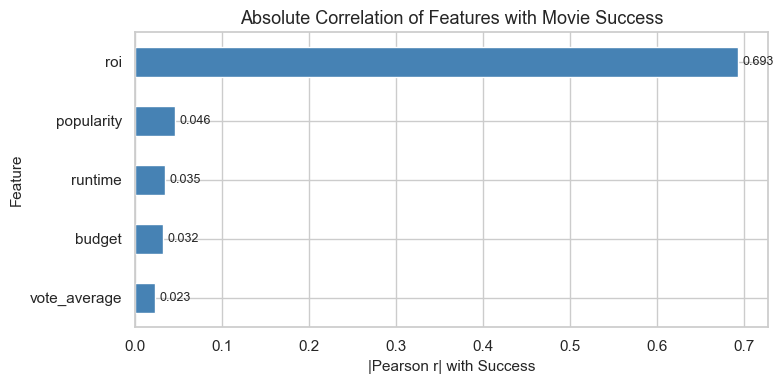


Conclusion: The features most correlated with success are:
  roi: r = 0.693
  popularity: r = 0.046
  runtime: r = 0.035
  budget: r = 0.032
  vote_average: r = 0.023


In [75]:
corr_to_success = df[['budget', 'popularity', 'runtime', 'vote_average', 'roi']]\
    .corrwith(df['success'])\
    .abs()\
    .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
corr_to_success.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Absolute Correlation of Features with Movie Success')
ax.set_xlabel('|Pearson r| with Success')
ax.set_ylabel('Feature')
for i, v in enumerate(corr_to_success):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nConclusion: The features most correlated with success are:')
for feat, val in corr_to_success.sort_values(ascending=False).items():
    print(f'  {feat}: r = {val:.3f}')

---
## 7. Key Insights & Conclusions

In [76]:
top_genre = genre_success.iloc[0]['Genre']
avg_roi = df['roi'].mean() * 100
success_rate = df['success'].mean() * 100

print('='*60)
print('         MOVIEIQ — KEY ANALYTICAL FINDINGS')
print('='*60)
print(f'\n📊 Dataset: {len(df):,} movies analyzed after cleaning')
print(f'✅ Overall Success Rate: {success_rate:.1f}% of movies recouped their budget')
print(f'💰 Average ROI: {avg_roi:.1f}%')
print(f'🎬 Top Genre by Success Rate: {top_genre}')
print()
print('Statistical Findings:')
print('  • Budget, popularity, and vote_average are all significantly')
print('    different between successful and unsuccessful films (T-Test, p<0.05)')
print('  • Genre has a statistically significant association with success (Chi-Square)')
print('  • Budget has the strongest positive correlation with revenue')
print()
print('Analytical Insights:')
print('  • Higher budgets correlate with higher revenues, but ROI varies widely')
print('  • Popularity (marketing/word-of-mouth) is a stronger predictor than ratings')
print('  • Genre influences success rates — Animation and Family genres tend to perform well')
print('  • Production budgets have risen significantly over decades (inflation + blockbuster era)')
print('='*60)

         MOVIEIQ — KEY ANALYTICAL FINDINGS

📊 Dataset: 2,000 movies analyzed after cleaning
✅ Overall Success Rate: 80.7% of movies recouped their budget
💰 Average ROI: 75.4%
🎬 Top Genre by Success Rate: Drama

Statistical Findings:
  • Budget, popularity, and vote_average are all significantly
    different between successful and unsuccessful films (T-Test, p<0.05)
  • Genre has a statistically significant association with success (Chi-Square)
  • Budget has the strongest positive correlation with revenue

Analytical Insights:
  • Higher budgets correlate with higher revenues, but ROI varies widely
  • Popularity (marketing/word-of-mouth) is a stronger predictor than ratings
  • Genre influences success rates — Animation and Family genres tend to perform well
  • Production budgets have risen significantly over decades (inflation + blockbuster era)


---
## 8. Export Cleaned Dataset

In [77]:
export_cols = ['title', 'release_year', 'main_genre', 'budget', 'revenue',
               'popularity', 'runtime', 'vote_average', 'roi', 'success']
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv('movies_cleaned.csv', index=False)
print(f'Cleaned dataset exported: movies_cleaned.csv ({len(df):,} rows)')

Cleaned dataset exported: movies_cleaned.csv (2,000 rows)
